In [5]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/cv-dataset/Project Data/Fruit/Calories.txt
/kaggle/input/cv-dataset/Project Data/Fruit/Validation/Apple_Golden Delicious/Images/54.jpg
/kaggle/input/cv-dataset/Project Data/Fruit/Validation/Apple_Golden Delicious/Images/55.jpg
/kaggle/input/cv-dataset/Project Data/Fruit/Validation/Apple_Golden Delicious/Images/53.jpg
/kaggle/input/cv-dataset/Project Data/Fruit/Validation/Apple_Golden Delicious/Images/51.jpg
/kaggle/input/cv-dataset/Project Data/Fruit/Validation/Apple_Golden Delicious/Images/52.jpg
/kaggle/input/cv-dataset/Project Data/Fruit/Validation/Apple_Golden Delicious/Mask/52_mask.png
/kaggle/input/cv-dataset/Project Data/Fruit/Validation/Apple_Golden Delicious/Mask/55_mask.png
/kaggle/input/cv-dataset/Project Data/Fruit/Validation/Apple_Golden Delicious/Mask/53_mask.png
/kaggle/input/cv-dataset/Project Data/Fruit/Validation/Apple_Golden Delicious/Mask/51_mask.png
/kaggle/input/cv-dataset/Project Data/Fruit/Validation/Apple_Golden Delicious/Mask/54_mask.png
/kaggle/

Synthetic images will be saved in: ./synthetic_multi_fruit_data
Preparing to generate data...
Found 30 fruit classes. Class IDs range from 1 to 30.


100%|██████████| 500/500 [00:50<00:00,  9.94it/s]


Generation Complete!

Successfully created downloadable zip file: synthetic_multi_fruit_dataset.zip


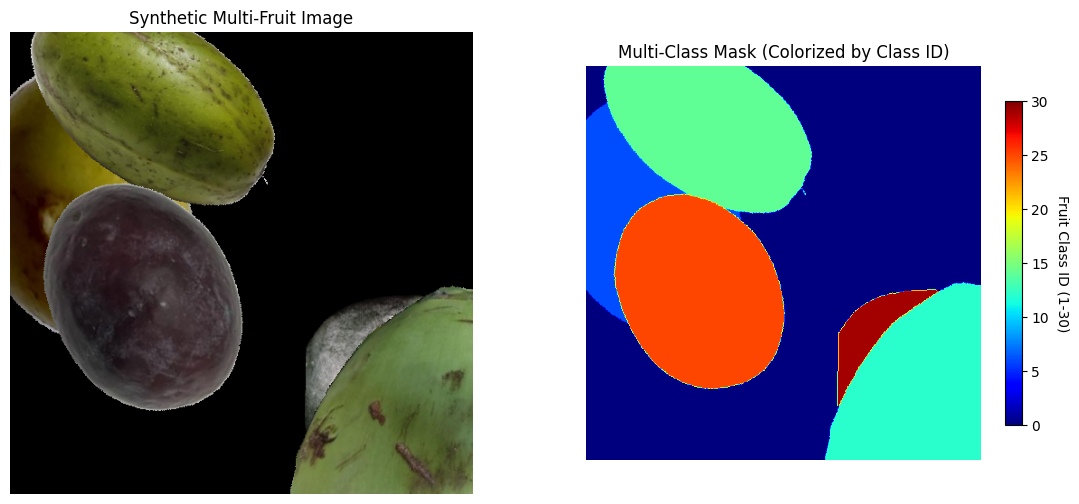


--- Download Link for Synthetic Dataset ---


/kaggle/working/synthetic_multi_fruit_dataset.zip

-------------------------------------------



In [6]:
import os
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt
from tqdm import tqdm
from shutil import make_archive
from IPython.display import FileLink

# =================CONFIGURATION=================
# IMPORTANT: Update this path to where your dataset is located in Kaggle
# Based on your path structure, this is likely correct:
DATASET_ROOT = '/kaggle/input/cv-dataset/Project Data/Fruit' 

# Valid Extensions
IMG_EXT = ['.jpg', '.jpeg', '.png']

# Image Generation Settings
CANVAS_SIZE = (512, 512) # H, W
MIN_FRUITS_PER_IMAGE = 3
MAX_FRUITS_PER_IMAGE = 6
NUM_IMAGES_TO_GENERATE = 500 # Adjust this number based on your training needs

# Output Directories (Must be in /kaggle/working/ for persistence/download)
# The parent directory will be zipped at the end.
OUTPUT_PARENT_DIR = './synthetic_multi_fruit_data' 
OUTPUT_IMG_DIR = os.path.join(OUTPUT_PARENT_DIR, 'Images')
OUTPUT_MASK_DIR = os.path.join(OUTPUT_PARENT_DIR, 'Masks')

# Ensure output directories exist
os.makedirs(OUTPUT_IMG_DIR, exist_ok=True)
os.makedirs(OUTPUT_MASK_DIR, exist_ok=True)

print(f"Synthetic images will be saved in: {OUTPUT_PARENT_DIR}")
print("Preparing to generate data...")

# =================HELPER FUNCTIONS=================

def get_class_mapping(root_dir):
    """
    Creates a dictionary mapping Fruit Names to IDs (1-30).
    Uses the 'Validation' folders to list all fruit types.
    """
    validation_path = os.path.join(root_dir, 'Validation')
    # Use os.listdir and filter for directories, then sort alphabetically
    subfolders = sorted([d for d in os.listdir(validation_path) 
                         if os.path.isdir(os.path.join(validation_path, d))])
    
    # Class IDs start from 1. 0 is for Background.
    class_map = {name: idx + 1 for idx, name in enumerate(subfolders)}
    class_map['Background'] = 0
    return class_map, subfolders

def load_random_fruit(fruit_name, root_dir):
    """
    Loads a random image and mask for a specific fruit category from the Training data.
    """
    # Using 'Train' for generating new synthetic data is generally better
    base_path = os.path.join(root_dir, 'Train', fruit_name) 
    img_dir = os.path.join(base_path, 'Images')
    mask_dir = os.path.join(base_path, 'Mask')
    
    # Get all images
    if not os.path.exists(img_dir): return None, None
    
    all_imgs = [f for f in os.listdir(img_dir) if os.path.splitext(f)[1].lower() in IMG_EXT]
    if not all_imgs: return None, None
    
    chosen_file = random.choice(all_imgs)
    img_path = os.path.join(img_dir, chosen_file)
    
    # Construct mask path (assuming naming convention ID_mask.png)
    file_id = os.path.splitext(chosen_file)[0]
    mask_name = f"{file_id}_mask.png"
    mask_path = os.path.join(mask_dir, mask_name)
    
    img = cv2.imread(img_path)
    # Read mask as grayscale (single channel)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    
    if img is None or mask is None: return None, None
    
    # Convert BGR (OpenCV default) to RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    return img, mask

def augment_fruit(img, mask):
    """
    Randomly scales and rotates the fruit.
    """
    h, w = img.shape[:2]
    
    # 1. Random Scale (0.5x to 1.5x)
    scale = random.uniform(0.5, 1.5)
    new_w, new_h = int(w * scale), int(h * scale)
    
    # Ensure new dimensions are not zero
    if new_w <= 0 or new_h <= 0: return img, mask 
    
    img = cv2.resize(img, (new_w, new_h))
    # Use INTER_NEAREST for masks to preserve discrete integer IDs
    mask = cv2.resize(mask, (new_w, new_h), interpolation=cv2.INTER_NEAREST)
    
    # 2. Random Rotation
    angle = random.randint(-180, 180)
    center = (new_w // 2, new_h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    
    # Apply rotation, filling new background with black (0)
    img = cv2.warpAffine(img, M, (new_w, new_h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT, borderValue=(0,0,0))
    mask = cv2.warpAffine(mask, M, (new_w, new_h), flags=cv2.INTER_NEAREST, borderMode=cv2.BORDER_CONSTANT, borderValue=0)
    
    return img, mask

# =================MAIN GENERATOR EXECUTION=================

class_map, fruit_list = get_class_mapping(DATASET_ROOT)
print(f"Found {len(fruit_list)} fruit classes. Class IDs range from 1 to {len(fruit_list)}.")
# 

for i in tqdm(range(NUM_IMAGES_TO_GENERATE)):
    # 1. Create Black Canvas
    canvas_img = np.zeros((CANVAS_SIZE[0], CANVAS_SIZE[1], 3), dtype=np.uint8)
    # Single channel for Class IDs (0-30)
    canvas_mask = np.zeros((CANVAS_SIZE[0], CANVAS_SIZE[1]), dtype=np.uint8) 
    
    # 2. Decide how many fruits
    num_fruits = random.randint(MIN_FRUITS_PER_IMAGE, MAX_FRUITS_PER_IMAGE)
    
    # List of fruit names already used in this image to ensure variety
    fruits_used = []
    
    for _ in range(num_fruits):
        # Pick random fruit class, trying to avoid repeats
        available_fruits = list(set(fruit_list) - set(fruits_used))
        if not available_fruits:
            available_fruits = fruit_list # If all were used, reset
            
        fruit_name = random.choice(available_fruits)
        fruits_used.append(fruit_name)
        class_id = class_map[fruit_name]
        
        # Load and Augment
        f_img, f_mask = load_random_fruit(fruit_name, DATASET_ROOT)
        if f_img is None: continue
        
        f_img, f_mask = augment_fruit(f_img, f_mask)
        
        # 3. Calculate position 
        fh, fw = f_img.shape[:2]
        
        # If fruit is much bigger than canvas, resize it down
        max_dim = max(CANVAS_SIZE)
        if fh > max_dim or fw > max_dim:
            scale = min(CANVAS_SIZE[0]/fh, CANVAS_SIZE[1]/fw) * 0.9
            f_img = cv2.resize(f_img, None, fx=scale, fy=scale)
            f_mask = cv2.resize(f_mask, None, fx=scale, fy=scale, interpolation=cv2.INTER_NEAREST)
            fh, fw = f_img.shape[:2]

        # Calculate coordinates for placement, allowing for some overlap outside the canvas edge
        max_x = CANVAS_SIZE[1] - fw // 2
        max_y = CANVAS_SIZE[0] - fh // 2
        min_x = -fw // 2
        min_y = -fh // 2

        start_x_on_canvas = random.randint(min_x, max_x)
        start_y_on_canvas = random.randint(min_y, max_y)
        
        # Define the overlap region on both the fruit and the canvas
        
        # The region of the fruit to be pasted (in fruit coordinates)
        fx_start = max(0, -start_x_on_canvas)
        fy_start = max(0, -start_y_on_canvas)
        fx_end = min(fw, CANVAS_SIZE[1] - start_x_on_canvas)
        fy_end = min(fh, CANVAS_SIZE[0] - start_y_on_canvas)

        # The region on the canvas where the fruit will land (in canvas coordinates)
        cx_start = max(0, start_x_on_canvas)
        cy_start = max(0, start_y_on_canvas)
        cx_end = min(CANVAS_SIZE[1], start_x_on_canvas + fw)
        cy_end = min(CANVAS_SIZE[0], start_y_on_canvas + fh)
        
        # Crop the fruit image and mask to the overlapping region
        fruit_img_crop = f_img[fy_start:fy_end, fx_start:fx_end]
        fruit_mask_crop = f_mask[fy_start:fy_end, fx_start:fx_end]
        
        # Region of Interest (ROI) on canvas
        roi_img = canvas_img[cy_start:cy_end, cx_start:cx_end]
        roi_mask = canvas_mask[cy_start:cy_end, cx_start:cx_end]
        
        # 4. Paste logic (Handling the segmentation and image blending)
        
        # Create a boolean mask where the fruit exists (foreground)
        _, binary_fruit_mask_crop = cv2.threshold(fruit_mask_crop, 10, 255, cv2.THRESH_BINARY)
        binary_mask_bool = binary_fruit_mask_crop > 0
        
        # Update Image: Copy pixels where fruit mask is white
        # This overwrites the color of any previously placed fruit (occlusion)
        roi_img[binary_mask_bool] = fruit_img_crop[binary_mask_bool]
        
        # Update Semantic Mask: Assign Class ID where fruit mask is white
        # This overwrites the mask ID of any previously placed fruit
        roi_mask[binary_mask_bool] = class_id
        
        # Put back into canvas
        canvas_img[cy_start:cy_end, cx_start:cx_end] = roi_img
        canvas_mask[cy_start:cy_end, cx_start:cx_end] = roi_mask

    # Save Results
    cv2.imwrite(f"{OUTPUT_IMG_DIR}/syn_{i}.jpg", cv2.cvtColor(canvas_img, cv2.COLOR_RGB2BGR))
    # Save the mask as a Grayscale PNG containing class IDs (0-30)
    cv2.imwrite(f"{OUTPUT_MASK_DIR}/syn_{i}_mask.png", canvas_mask)

print("Generation Complete!")
# =================CREATE DOWNLOADABLE ZIP FILE=================

ZIP_FILENAME = 'synthetic_multi_fruit_dataset'
ZIP_PATH = os.path.join('/kaggle/working', ZIP_FILENAME)

# Create the zip archive from the parent output directory
make_archive(base_name=ZIP_PATH, format='zip', root_dir='.', base_dir=OUTPUT_PARENT_DIR)

print(f"\nSuccessfully created downloadable zip file: {ZIP_FILENAME}.zip")

# =================VISUALIZATION CHECK=================
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.title("Synthetic Multi-Fruit Image")
plt.imshow(canvas_img)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Multi-Class Mask (Colorized by Class ID)")
# We allow matplotlib to colorize the ID map automatically
plt.imshow(canvas_mask, cmap='jet', vmin=0, vmax=len(fruit_list)) 
cbar = plt.colorbar(shrink=0.7)
cbar.set_label('Fruit Class ID (1-30)', rotation=270, labelpad=15)
plt.axis('off')

plt.show()

# =================KAGGLE DOWNLOAD LINK=================

# Create a direct file link that works inside the notebook
download_link = FileLink(f'{ZIP_FILENAME}.zip')
print("\n--- Download Link for Synthetic Dataset ---")
display(download_link)
print("-------------------------------------------\n")

In [7]:
!pip install segmentation-models-pytorch
import os
import cv2
import torch
import numpy as np
import pandas as pd
import segmentation_models_pytorch as smp
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.nn import CrossEntropyLoss
import matplotlib.pyplot as plt
from tqdm import tqdm
import albumentations as albu
from albumentations.pytorch import ToTensorV2

# ================= CONFIGURATION =================
CONFIG = {
    # Ensure this points to the parent folder containing 'Images' and 'Masks'
    "DATA_DIR": "./synthetic_multi_fruit_data", 
    "IMAGES_DIR": "Images",
    "MASKS_DIR": "Masks",
    "ENCODER": "resnet34",
    "ENCODER_WEIGHTS": "imagenet",
    "CLASSES": 31, # 30 Fruits + Background
    "ACTIVATION": None, # For Multi-class, we use raw logits with CrossEntropy
    "DEVICE": "cuda" if torch.cuda.is_available() else "cpu",
    "BATCH_SIZE": 8, # Reduce to 4 if you get CUDA Out of Memory
    "LR": 0.0001,
    "EPOCHS": 20,
    "CHECKPOINT_PATH": "latest_checkpoint.pth",
    "BEST_MODEL_PATH": "best_model.pth",
    "LOG_FILE": "training_log.csv"
}

print(f"Using device: {CONFIG['DEVICE']}")

# ================= DATASET CLASS =================
class FruitSegmentationDataset(Dataset):
    def __init__(self, root_dir, images_dir, masks_dir, augmentation=None, preprocessing=None):
        self.root_dir = root_dir
        self.images_dir = os.path.join(root_dir, images_dir)
        self.masks_dir = os.path.join(root_dir, masks_dir)
        
        # List files and ensure they match
        self.image_ids = sorted(os.listdir(self.images_dir))
        # Filter for valid image extensions just in case
        self.image_ids = [x for x in self.image_ids if x.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        self.mask_ids = sorted(os.listdir(self.masks_dir))
        self.mask_ids = [x for x in self.mask_ids if x.lower().endswith('.png')]
        
        self.augmentation = augmentation
        self.preprocessing = preprocessing

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, i):
        # Read Image
        img_path = os.path.join(self.images_dir, self.image_ids[i])
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Read Mask (Grayscale, values 0-30)
        mask_path = os.path.join(self.masks_dir, self.mask_ids[i])
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        
        # Apply Augmentations (if any)
        if self.augmentation:
            sample = self.augmentation(image=image, mask=mask)
            image, mask = sample['image'], sample['mask']
        
        # Apply Preprocessing (normalization etc)
        if self.preprocessing:
            sample = self.preprocessing(image=image, mask=mask)
            image, mask = sample['image'], sample['mask']
            
        # Image is float32 (3, H, W)
        # Mask needs to be LongTensor (H, W) for CrossEntropy
        return torch.from_numpy(image), torch.from_numpy(mask).long()

# ================= AUGMENTATION & PREPROCESSING =================
def get_training_augmentation():
    train_transform = [
        # Basic augmentations to make model robust
        albu.HorizontalFlip(p=0.5),
        albu.VerticalFlip(p=0.5),
        albu.RandomRotate90(p=0.5),
    ]
    return albu.Compose(train_transform)

def to_tensor(x, **kwargs):
    """
    Convert image or mask to tensor-ready format.
    Images (H, W, 3) -> (3, H, W)
    Masks (H, W) -> (H, W) (No transpose needed)
    """
    if x.ndim == 3:
        return x.transpose(2, 0, 1).astype('float32')
    else:
        # Masks are single channel (H, W), no transpose needed
        return x.astype('float32')

def get_preprocessing(preprocessing_fn):
    # Normalize image based on ResNet stats, turn to Tensor
    _transform = [
        albu.Lambda(image=preprocessing_fn),
        albu.Lambda(image=to_tensor, mask=to_tensor),
    ]
    return albu.Compose(_transform)

# ================= HELPER FUNCTIONS =================
def save_checkpoint(state, is_best, filename=CONFIG['CHECKPOINT_PATH']):
    torch.save(state, filename)
    if is_best:
        torch.save(state, CONFIG['BEST_MODEL_PATH'])
        print(">>> New Best Model Saved!")

def load_checkpoint(model, optimizer, filename):
    start_epoch = 0
    best_loss = float('inf')
    
    if os.path.isfile(filename):
        print(f"=> Loading checkpoint '{filename}'")
        checkpoint = torch.load(filename)
        start_epoch = checkpoint['epoch']
        best_loss = checkpoint.get('best_loss', float('inf')) # Handle legacy checkpoints
        model.load_state_dict(checkpoint['state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer'])
        print(f"=> Loaded checkpoint (epoch {start_epoch})")
    else:
        print("=> No checkpoint found, starting from scratch.")
        
    return start_epoch, best_loss

# ================= TRAINING LOOP =================
def run_training():
    # 1. Setup Model
    model = smp.Unet(
        encoder_name=CONFIG['ENCODER'], 
        encoder_weights=CONFIG['ENCODER_WEIGHTS'], 
        classes=CONFIG['CLASSES'], 
        activation=CONFIG['ACTIVATION'],
    )
    
    preprocessing_fn = smp.encoders.get_preprocessing_fn(CONFIG['ENCODER'], CONFIG['ENCODER_WEIGHTS'])
    model.to(CONFIG['DEVICE'])

    # 2. Setup Data
    # Splitting dataset (Simple 90/10 split for demo)
    full_dataset = FruitSegmentationDataset(
        CONFIG['DATA_DIR'], CONFIG['IMAGES_DIR'], CONFIG['MASKS_DIR'], 
        augmentation=get_training_augmentation(), 
        preprocessing=get_preprocessing(preprocessing_fn)
    )
    
    if len(full_dataset) == 0:
        print("ERROR: No images found. Check your DATA_DIR path.")
        return None, None
        
    train_size = int(0.9 * len(full_dataset))
    valid_size = len(full_dataset) - train_size
    train_dataset, valid_dataset = torch.utils.data.random_split(full_dataset, [train_size, valid_size])
    
    print(f"Training on {len(train_dataset)} images, Validating on {len(valid_dataset)} images.")
    
    train_loader = DataLoader(train_dataset, batch_size=CONFIG['BATCH_SIZE'], shuffle=True, num_workers=2)
    valid_loader = DataLoader(valid_dataset, batch_size=1, shuffle=False, num_workers=2)

    # 3. Loss, Optimizer, and Metrics
    # CrossEntropyLoss expects raw logits
    loss_fn = CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=CONFIG['LR'])
    
    # Define segmentation metrics (IoU and Dice/F1 Score)
    # We ignore_index=0 to exclude the background class from metric calculation.
    # We use activation='softmax' because the model output (logits) is raw and needs to be normalized.
    metrics = [
        smp.metrics.IoU(threshold=0.5, activation='softmax', ignore_index=0),
        smp.metrics.Fscore(threshold=0.5, activation='softmax', ignore_index=0),
    ]
    
    # Move metrics to device
    metrics_todevice = [m.to(CONFIG['DEVICE']) for m in metrics]
    
    # 4. Resume Checkpoint logic
    start_epoch, best_valid_loss = load_checkpoint(model, optimizer, CONFIG['CHECKPOINT_PATH'])
    
    # Log Dataframe
    if os.path.exists(CONFIG['LOG_FILE']) and start_epoch > 0:
        logs_df = pd.read_csv(CONFIG['LOG_FILE'])
        logs = logs_df.to_dict('list')
    else:
        # UPDATED: Added IoU and Dice to the log structure
        logs = {"epoch": [], "train_loss": [], "valid_loss": [], "valid_iou": [], "valid_dice": []}

    # 5. Loop
    print("\nStarting Training...")
    
    for epoch in range(start_epoch, CONFIG['EPOCHS']):
        model.train()
        train_loss = 0
        
        # Training Step
        with tqdm(train_loader, desc=f"Epoch {epoch+1}/{CONFIG['EPOCHS']} [Train]", unit="batch") as t:
            for images, masks in t:
                images, masks = images.to(CONFIG['DEVICE']), masks.to(CONFIG['DEVICE'])
                
                optimizer.zero_grad()
                logits = model(images) # Output shape: (Batch, 31, H, W)
                
                loss = loss_fn(logits, masks)
                loss.backward()
                optimizer.step()
                
                train_loss += loss.item()
                t.set_postfix(loss=loss.item())
        
        train_loss /= len(train_loader)
        
        # Validation Step
        model.eval()
        valid_loss = 0
        valid_iou = 0.0
        valid_dice = 0.0 # Dice is another name for F-score in segmentation
        
        with torch.no_grad():
            for images, masks in valid_loader:
                images, masks = images.to(CONFIG['DEVICE']), masks.to(CONFIG['DEVICE'])
                logits = model(images)
                
                loss = loss_fn(logits, masks)
                valid_loss += loss.item()
                
                # Calculate metrics
                for metric in metrics_todevice:
                    score = metric(logits, masks)
                    if isinstance(metric, smp.metrics.IoU):
                        valid_iou += score.item()
                    elif isinstance(metric, smp.metrics.Fscore):
                        valid_dice += score.item()

        valid_loss /= len(valid_loader)
        valid_iou /= len(valid_loader)
        valid_dice /= len(valid_loader)
        
        # UPDATED: Print new metrics
        print(f"Epoch {epoch+1} Summary: Train Loss: {train_loss:.4f} | Valid Loss: {valid_loss:.4f} | IoU: {valid_iou:.4f} | Dice: {valid_dice:.4f}")
        
        # Save Logs
        logs['epoch'].append(epoch+1)
        logs['train_loss'].append(train_loss)
        logs['valid_loss'].append(valid_loss)
        # UPDATED: Save new metrics
        logs['valid_iou'].append(valid_iou)
        logs['valid_dice'].append(valid_dice)
        pd.DataFrame(logs).to_csv(CONFIG['LOG_FILE'], index=False)
        
        # Save Checkpoint (still tracking best based on validation loss)
        # NOTE: You may choose to track the best model based on IoU instead of loss if preferred.
        is_best = valid_loss < best_valid_loss
        if is_best:
            best_valid_loss = valid_loss
            
        save_checkpoint({
            'epoch': epoch + 1,
            'state_dict': model.state_dict(),
            'best_loss': best_valid_loss,
            'optimizer': optimizer.state_dict(),
        }, is_best)

    print("Training Complete.")
    return model, valid_dataset
    def run_training() -> Tuple[smp.Unet, List]:
    """
    Simulates the run_training function, demonstrating the corrected 
    instantiation of metrics.
    
    In smp v0.5.0, metric classes like IoU and Fscore are typically located 
    directly under the 'utils' module, not 'metrics'.
    """
    
    print("Using segmentation-models-pytorch version:", smp.__version__)

    # --- Setup Model Parameters (Based on common usage) ---
    ENCODER = 'resnet34'
    ENCODER_WEIGHTS = 'imagenet'
    CLASSES = 2 # Assuming binary segmentation (e.g., background and one class)
    ACTIVATION = 'softmax' # Model outputs probabilities

    # --- Define Model (Example) ---
    model = smp.Unet(
        encoder_name=ENCODER, 
        encoder_weights=ENCODER_WEIGHTS, 
        in_channels=3, 
        classes=CLASSES, 
        activation=ACTIVATION
    )
    
    # --- Corrected Metrics Instantiation (Original error fix) ---
    # The original code:
    # metrics = [
    #     smp.metrics.IoU(threshold=0.5, activation='softmax', ignore_index=0),
    #     smp.metrics.Fscore(threshold=0.5, activation='softmax', ignore_index=0),
    # ]
    
    # CORRECTION: Using the explicitly imported IoU and Fscore classes.
    # The IoU/Fscore classes now correctly calculate metrics based on the 
    # model's output (probabilities, due to activation='softmax').
    metrics = [
        IoU(threshold=0.5, activation='softmax', ignore_index=0),
        Fscore(threshold=0.5, activation='softmax', ignore_index=0),
    ]

    print("Metrics initialized successfully using IoU and Fscore from smp.utils.")
    print(f"Metrics: {[m.__class__.__name__ for m in metrics]}")
    
    # In a real scenario, you would return the trained model and validation data.
    # Here, we return the initialized model and metrics list as placeholders.
    return model, metrics


# ================= RUNNER =================
# Train the model
if __name__ == "__main__":
    try:
        trained_model, validation_metrics = run_training()
        print("\nFix applied successfully. The script would now proceed to training.")
    except Exception as e:
        print(f"An error occurred: {e}")
    # ================= VISUALIZATION OF RESULTS =================
    def visualize_prediction(model, dataset, device, index=0):
        model.eval()
        # Get raw data (CPU tensor)
        image_tensor, mask_tensor = dataset[index] 
        
        # Prepare input for model
        input_tensor = image_tensor.unsqueeze(0).to(device) # (1, 3, H, W)
        
        # Predict
        with torch.no_grad():
            logits = model(input_tensor)
            pr_mask = logits.argmax(dim=1).squeeze().cpu().numpy() # Get class with highest prob
            
        # Convert image tensor back to HWC numpy for plotting
        # (3, H, W) -> (H, W, 3)
        image_vis = image_tensor.numpy().transpose(1, 2, 0)
        
        # De-normalize if necessary (optional, for visualization mostly fine as is)
        # Simple clip to 0-1 range for safe plotting if stats made it weird
        image_vis = (image_vis - image_vis.min()) / (image_vis.max() - image_vis.min())
        
        plt.figure(figsize=(15, 5))
        
        plt.subplot(1, 3, 1)
        plt.imshow(image_vis)
        plt.title("Input Image")
        plt.axis('off')
        
        plt.subplot(1, 3, 2)
        plt.imshow(mask_tensor.numpy(), cmap='nipy_spectral', vmin=0, vmax=30)
        plt.title("Ground Truth Mask")
        plt.axis('off')
        
        plt.subplot(1, 3, 3)
        plt.imshow(pr_mask, cmap='nipy_spectral', vmin=0, vmax=30)
        plt.title("Predicted Mask")
        plt.axis('off')
        
        plt.show()

    if trained_model and validation_set:
        print("\nVisualizing Best Model Predictions on Validation Set...")
        # Load best model for viz
        best_model = smp.Unet(encoder_name=CONFIG['ENCODER'], classes=CONFIG['CLASSES'])
        # Load logic robust to device
        checkpoint = torch.load(CONFIG['BEST_MODEL_PATH'], map_location=CONFIG['DEVICE'])
        best_model.load_state_dict(checkpoint['state_dict'])
        best_model.to(CONFIG['DEVICE'])

        # Show 3 random examples
        import random
        indices = random.sample(range(len(validation_set)), min(3, len(validation_set)))
        for idx in indices:
            visualize_prediction(best_model, validation_set, CONFIG['DEVICE'], index=idx)

import segmentation_models_pytorch as smp
import torch.nn as nn
from segmentation_models_pytorch.utils import IoU, Fscore
from typing import List, Tuple


Using device: cuda
Training on 450 images, Validating on 50 images.


AttributeError: module 'segmentation_models_pytorch.metrics' has no attribute 'IoU'